In [1]:
import os
if os.getenv("COLAB_RELEASE_TAG"):
    import subprocess
    subprocess.run('wget https://raw.githubusercontent.com/luigibonati/mlcolvar/main/colab_setup.sh', shell=True)
    cmd = subprocess.run('bash colab_setup.sh TUTORIAL', shell=True, stdout=subprocess.PIPE)
    print(cmd.stdout.decode('utf-8'))

# IMPORT PACKAGES
import torch
import lightning
import numpy as np
import matplotlib.pyplot as plt

# IMPORT HELPER FUNCTIONS
from mlcolvar.utils.plot import muller_brown_potential, plot_isolines_2D, plot_metrics

# Set seed for reproducibility
torch.manual_seed(42)

/home/sompriya/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
import pandas as pd
from mlcolvar.utils.io import load_dataframe
from mlcolvar.utils.timelagged import create_timelagged_dataset
from mlcolvar.data import DictModule
import numpy as np


df = load_dataframe('COLVAR_multiT_new',start=10000,stop=100000)
df

/home/sompriya/.local/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.1' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/home/sompriya/.local/lib/python3.10/site-packages/pandas/core/arrays/masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (


,time,lassoCV_node0,lassoCV_node1,ene,ecv.ene,opes.bias,cos1,cos2,cos3,cos4,...,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24,walker
0,10000.000475,0.269999,0.423428,-80102.226562,-80102.226562,-121.706353,0.779324,0.278103,-0.776469,0.621036,...,0.256800,-0.747058,0.358753,-0.879230,0.135160,-0.993983,0.567677,0.121172,-0.961886,0
1,10001.000475,0.186971,0.554292,-80711.296875,-80711.296875,-34.851420,0.612987,0.432302,-0.345622,0.291808,...,0.112500,-0.563409,0.420615,-0.965964,0.473395,-0.923319,0.392391,0.455388,-0.996598,0
2,10002.000475,0.259937,0.492581,-80493.968750,-80493.968750,-62.687289,0.919886,0.231121,-0.517989,0.426839,...,0.159139,-0.612105,0.568901,-0.997896,0.457916,-0.997763,0.625798,0.255404,-0.857996,0
3,10003.000475,0.210614,0.484649,-80855.351562,-80855.351562,-20.162228,0.707806,0.328715,-0.483719,0.539147,...,0.029736,-0.512285,0.436132,-0.880161,0.390952,-0.995649,0.390429,0.242572,-0.798044,0
4,10004.000475,0.222392,0.601231,-80528.820312,-80528.820312,-57.832260,0.778533,0.395043,-0.489986,0.352418,...,0.216976,-0.459987,0.414488,-0.918131,0.170774,-0.999121,0.383146,0.250702,-0.966554,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89995,99995.004750,0.205461,0.475227,-80967.289062,-80967.289062,-10.529125,0.498474,-0.067815,-0.800521,0.566641,...,0.202317,-0.997964,0.386013,-0.968600,0.552945,-0.994782,0.557881,-0.665203,-0.827287,0
89996,99996.004750,0.171005,0.472516,-81354.156250,-81354.156250,3.422625,0.714778,0.103997,-0.634132,0.560077,...,0.253739,-0.745868,0.617348,-0.944644,0.310395,-0.994644,0.558188,-0.752622,-0.921983,0
89997,99997.004750,0.204140,0.466203,-81252.398438,-81252.398438,1.941719,0.514641,0.127614,-0.716095,0.774151,...,0.193534,-0.986302,0.534496,-0.909337,0.438104,-0.994762,0.640989,-0.751976,-0.899461,0
89998,99998.004750,0.220010,0.539126,-80431.367188,-80431.367188,-70.453871,0.432557,0.193188,-0.730123,0.834455,...,0.134103,-0.924619,0.539858,-0.899294,0.397531,-0.982238,0.480727,-0.701684,-0.806028,0


In [3]:
# Select input features
X = df.filter(regex='cos').values
n_input = X.shape[1]

print(X.shape)
print(X)

(90000, 24)
[[ 0.779324  0.278103 -0.776469 ...  0.567677  0.121172 -0.961886]
 [ 0.612987  0.432302 -0.345622 ...  0.392391  0.455388 -0.996598]
 [ 0.919886  0.231121 -0.517989 ...  0.625798  0.255404 -0.857996]
 ...
 [ 0.514641  0.127614 -0.716095 ...  0.640989 -0.751976 -0.899461]
 [ 0.432557  0.193188 -0.730123 ...  0.480727 -0.701684 -0.806028]
 [ 0.658677 -0.049543 -0.866602 ...  0.504574 -0.739946 -0.809601]]


In [4]:
#------------- PARAMETERS -------------
multicanonical    = True
temp              = 275.
temp0             = 275.
#--------------------------------------

# Calculate inverse temperature
kb=0.008314
beta=1./(kb*temp)
beta0=1./(kb*temp0)

# Extract cvs from df

t = df['time'].values # save time
ene = df['ene'].values.astype(np.float64) # store energy as long double
bias = df.filter(regex='.bias').values.sum(axis=1) # Load *.bias columns and sum them

# Compute log-weights for time reweighting
logweights = beta*bias

if multicanonical:
    ene -= np.mean(ene) #first shift energy by its mean value
    logweights += (beta0-beta)*ene

In [5]:
#------------- PARAMETERS -------------
lag_time = 100.
#--------------------------------------

# create dataset
dataset = create_timelagged_dataset(X,t,lag_time=lag_time,logweights=logweights,progress_bar=True)
#dataset = create_timelagged_dataset(X,t,lag_time=lag_time,progress_bar=True)

# create datamodule (split train valid)
datamodule = DictModule(dataset,lengths=[0.8,0.2],random_split=False,shuffle=False)

datamodule

100%|████████████████████████████████████| 89775/89775 [03:45<00:00, 398.67it/s]
/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/utils/timelagged.py:186: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at ../torch/csrc/utils/tensor_new.cpp:275.)
  x_t = torch.stack(x_t) if type(x) == torch.Tensor else torch.Tensor(x_t)
/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/data/datamodule.py:134: UserWarning: A torch.generator was provided but it is not used with random_split=False
  warnings.warn(


DictModule(dataset -> DictDataset( "data": [179156, 24], "data_lag": [179156, 24], "weights": [179156], "weights_lag": [179156] ),
		     train_loader -> DictLoader(length=0.8, batch_size=0, shuffle=False),
		     valid_loader -> DictLoader(length=0.2, batch_size=0, shuffle=False))

In [6]:
from mlcolvar.cvs import DeepTICA

n_components = 2
nn_layers = [n_input, 16, 12, 2]
options= {'nn': {'activation': 'shifted_softplus'}}

model = DeepTICA(nn_layers, n_cvs=n_components, options=options)
model

DeepTICA(
  (loss_fn): ReduceEigenvaluesLoss()
  (norm_in): Normalization(in_features=24, out_features=24, mode=mean_std)
  (nn): FeedForward(
    (nn): Sequential(
      (0): Linear(in_features=24, out_features=16, bias=True)
      (1): Shifted_Softplus(beta=1, threshold=20)
      (2): Linear(in_features=16, out_features=12, bias=True)
      (3): Shifted_Softplus(beta=1, threshold=20)
      (4): Linear(in_features=12, out_features=5, bias=True)
    )
  )
  (tica): TICA(in_features=5, out_features=2)
)

In [7]:
from lightning.pytorch.callbacks.early_stopping import EarlyStopping
from mlcolvar.utils.trainer import MetricsCallback

# define callbacks
metrics = MetricsCallback()
early_stopping = EarlyStopping(monitor="valid_loss", min_delta=1e-3, patience=100)

# define trainer
trainer = lightning.Trainer(callbacks=[metrics, early_stopping],
                     max_epochs=None, logger=None, enable_checkpointing=False)

# fit
torch.set_float32_matmul_precision('medium')
trainer.fit( model, datamodule )

Trainer will use only 1 of 2 GPUs because it is running inside an interactive / notebook environment. You may try to set `Trainer(devices=2)` but please note that multi-GPU inside interactive / notebook environments is considered experimental and unstable. Your mileage may vary.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/trainer/connectors/logger_connector/logger_connector.py:75: Starting from v1.9.0, `tensorboardX` has been removed as a dependency of the `lightning.pytorch` package, due to potential conflicts with other packages in the ML ecosystem. For this reason, `logger=True` will use `CSVLogger` as the default logger, unless the `tensorboard` or `tensorboardX` packages are found. Please `pip install lightning[extra]` or one of them to enable TensorBoard support by default
/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/

Sanity Checking: |                                        | 0/? [00:00<?, ?it/s]

/home/sompriya/.local/lib/python3.10/site-packages/lightning/pytorch/loops/fit_loop.py:298: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |                                               | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

...

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

Validation: |                                             | 0/? [00:00<?, ?it/s]

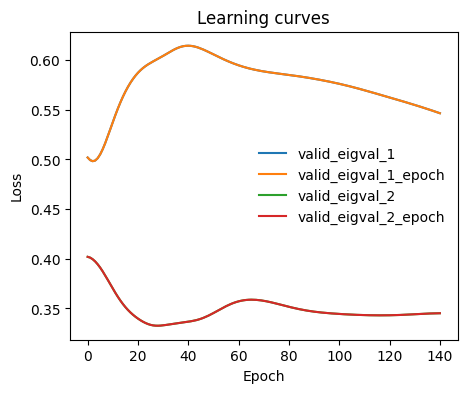

In [8]:
from mlcolvar.utils.plot import plot_metrics

ax = plot_metrics(metrics.metrics,
                  keys=[x for x in  metrics.metrics.keys() if 'valid_eigval' in x],#['train_loss_epoch','valid_loss'],
                  #linestyles=['-.','-'], colors=['fessa1','fessa5'],
                  yscale='linear')

In [9]:
from mlcolvar.core.transform import Normalization
from mlcolvar.core.transform.utils import Statistics

#X = dataset[:]['data']
with torch.no_grad():
    model.postprocessing = None # reset
    s = model(torch.Tensor(X))

norm =  Normalization(n_components, mode='min_max', stats = Statistics(s) )
model.postprocessing = norm

Text(0, 0.5, 'Deep-TICA 2')

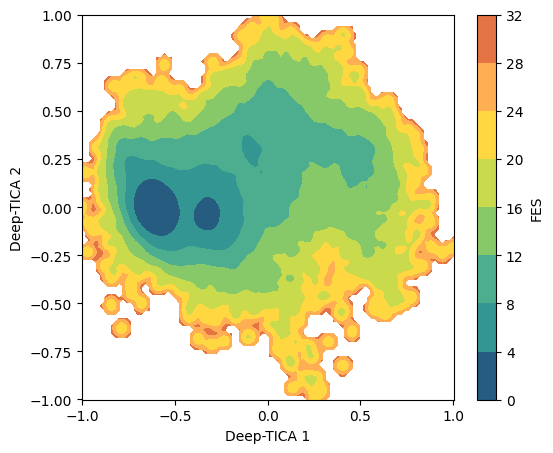

In [10]:
from mlcolvar.utils.fes import compute_fes

fig,ax = plt.subplots(1,1,figsize=(6,5),dpi=100)

# compute cvs
with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()

w = np.exp(logweights)
fes,grid,bounds,error = compute_fes(s,
                                    blocks=1, #weights=w,
                                    bandwidth=0.01, scale_by='range',
                                    plot=True, plot_max_fes=30, ax = ax, eps=1e-8)

ax.set_xlabel('Deep-TICA 1') 
ax.set_ylabel('Deep-TICA 2')
#plt.savefig('Deep_TICA_multiT_aaaa_mod.png',dpi=300,bbox_inches='tight')

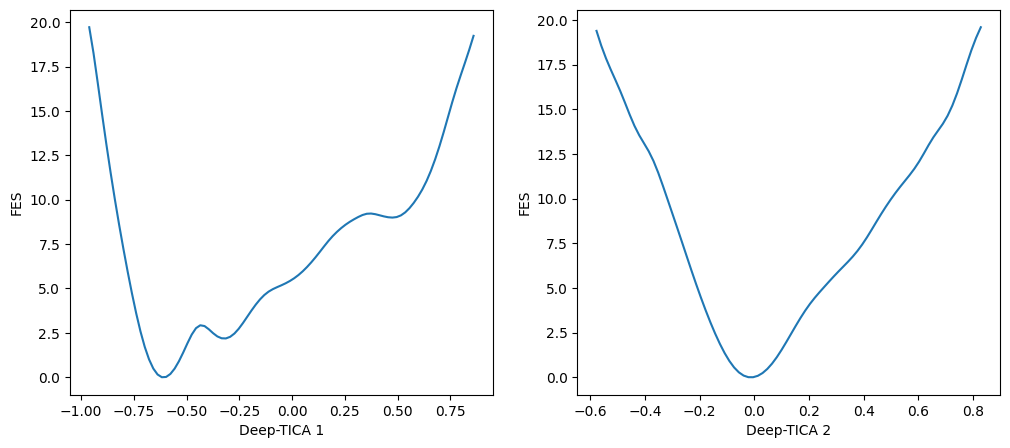

In [11]:
from mlcolvar.utils.fes import compute_fes

fig,axs = plt.subplots(1,n_components,figsize=(6*n_components,5),dpi=100)

for i in range(n_components):
    #w = np.exp(logweights)

    # restrict the second CV to the points in which the first is < 0
    fes,grid,bounds,error = compute_fes(s[:,i] if i == 0 else s[s[:,0] < 0, i ],
                                        #weights=w if i == 0 else w[s[:,0] < 0 ],
                                        blocks=1,
                                        bandwidth=0.02,scale_by='range',
                                        plot=True, plot_max_fes=20, ax = axs[i])
    axs[i].set_xlabel('Deep-TICA '+str(i+1))

In [12]:
## Save the model
x = torch.rand(n_input, dtype=torch.float32, requires_grad=True).unsqueeze(0)
traced_cv = torch.jit.trace ( model, example_inputs=x)
filename='rna_tetra_mutiT_deeptica_cccc_deshawff_mod.pt'
traced_cv.save(filename)

/home/sompriya/.local/lib/python3.10/site-packages/mlcolvar/core/nn/utils.py:13: TracerWarning: Converting a tensor to a Python number might cause the trace to be incorrect. We can't record the data flow of Python values, so this value will be treated as a constant in the future. This means that the trace might not generalize to other inputs!
  sp0 = F.softplus(torch.zeros(1), self.beta, self.threshold).item()
/home/sompriya/.local/lib/python3.10/site-packages/torch/jit/_trace.py:165: UserWarning: The .grad attribute of a Tensor that is not a leaf Tensor is being accessed. Its .grad attribute won't be populated during autograd.backward(). If you indeed want the .grad field to be populated for a non-leaf Tensor, use .retain_grad() on the non-leaf Tensor. If you access the non-leaf Tensor by mistake, make sure you access the leaf Tensor instead. See github.com/pytorch/pytorch/pull/30531 for more informations. (Triggered internally at aten/src/ATen/core/TensorBody.h:489.)
  if a.grad is n

In [13]:
#Lasso Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import LassoCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic0 = s[:,0]#select DeepTICA 1

reg0 = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X, tic0)
print(reg0.coef_)
print(reg0.intercept_)
np.savetxt('tica1_coeff.txt',reg0.coef_,fmt='%0.3f')

[-0.20927535 -0.20469368  0.17539343 -0.15845595 -0.07303735 -0.06482536
 -0.05472274  0.0509799   0.06445871 -0.08723247 -0.16242704 -0.02599004
 -0.08502821  0.25210056  0.08242685 -0.12107583 -0.15428016 -0.10203714
  0.11625828  0.0052541   0.09924544  0.01055174 -0.00563331 -0.08510475]
-0.09499463322999585


In [14]:
#Lasso Regression delete low weitage NN
from sklearn import linear_model
from sklearn.linear_model import LassoCV

with torch.no_grad():
    s = model(torch.Tensor(X)).numpy()
tic1 = s[:,1]#select DeepTICA 2

reg1 = LassoCV(cv=5, random_state=0, max_iter=10000).fit(X, tic1)
print(reg1.coef_)
print(reg1.intercept_)
np.savetxt('tica2_coeff.txt',reg1.coef_,fmt='%0.3f')

[ 0.0033343  -0.0616018   0.06895631 -0.1087085   0.05262375  0.11608363
 -0.50108967 -0.05364153 -0.33196311 -0.07448986  0.03961922 -0.15630883
 -0.17491333 -0.41759707  0.08363127  0.02536509  0.10238758  0.14086555
 -0.18174704 -0.05694448  0.11210874 -0.03206016 -0.10865727  0.03927086]
-0.9063231547402


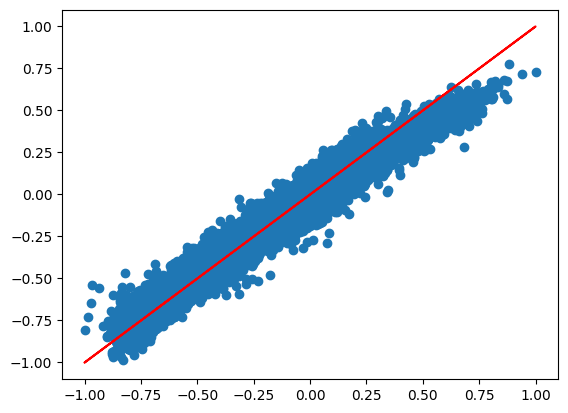

In [15]:
X_np = torch.Tensor(X).numpy()
ypred = reg0.predict(X)

plt.scatter(tic0,ypred)
plt.plot(tic0,tic0,c='r') # X axis=DeepTICA 1 CV, Y axis= lassoCV, 

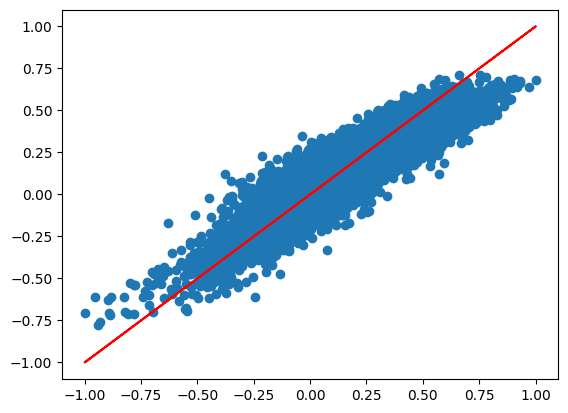

In [16]:
X_np = torch.Tensor(X).numpy()
ypred = reg1.predict(X)

plt.scatter(tic1,ypred)
plt.plot(tic1,tic1,c='r') # X axis=DeepTICA 2 CV, Y axis= lassoCV, 

In [17]:
s='lasso_node0: COMBINE ARG='
for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= 'cos%d'%(i+1)
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg0.coef_)):
    if reg0.coef_[i] != 0:
        s+= '%0.4f'%reg0.coef_[i]
        if i < len(reg0.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg0.coef_)
offset = reg0.intercept_
if offset>0:
    s2 = 'lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

lasso_node0: COMBINE ARG=cos1,cos2,cos3,cos4,cos5,cos6,cos7,cos8,cos9,cos10,cos11,cos12,cos13,cos14,cos15,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24 COEFFICIENTS=-0.2093,-0.2047,0.1754,-0.1585,-0.0730,-0.0648,-0.0547,0.0510,0.0645,-0.0872,-0.1624,-0.0260,-0.0850,0.2521,0.0824,-0.1211,-0.1543,-0.1020,0.1163,0.0053,0.0992,0.0106,-0.0056,-0.0851 PERIODIC=NO
 
lassoCV_node0: MATHEVAL ARG=lasso_node0 FUNC=x-0.0950 PERIODIC=NO


In [18]:
s='lasso_node1: COMBINE ARG='
for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= 'cos%d'%(i+1)
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' COEFFICIENTS='

for i in range(len(reg1.coef_)):
    if reg1.coef_[i] != 0:
        s+= '%0.4f'%reg1.coef_[i]
        if i < len(reg1.coef_) - 1:
            s+= ','
s+= ' PERIODIC=NO'
print(s)
print(' ')

#correct for offset
of_arr = ypred - np.dot(X_np,reg1.coef_)
offset = reg1.intercept_
if offset>0:
    s2 = 'lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x+%0.4f PERIODIC=NO'%offset
elif offset<0:
    s2 = 'lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x%0.4f PERIODIC=NO'%offset
print(s2)

lasso_node1: COMBINE ARG=cos1,cos2,cos3,cos4,cos5,cos6,cos7,cos8,cos9,cos10,cos11,cos12,cos13,cos14,cos15,cos16,cos17,cos18,cos19,cos20,cos21,cos22,cos23,cos24 COEFFICIENTS=0.0033,-0.0616,0.0690,-0.1087,0.0526,0.1161,-0.5011,-0.0536,-0.3320,-0.0745,0.0396,-0.1563,-0.1749,-0.4176,0.0836,0.0254,0.1024,0.1409,-0.1817,-0.0569,0.1121,-0.0321,-0.1087,0.0393 PERIODIC=NO
 
lassoCV_node1: MATHEVAL ARG=lasso_node1 FUNC=x-0.9063 PERIODIC=NO
